---
title: "Machine learning without labelling: finding every football pitch in London with `osm-rasterizer`"
subtitle: "*What if you could train a land-cover detector without hand-labelling a single pixel? (osm-rasterizer demo ft. Tessera)*"
date: "07/12/2026"
categories:
- phd
- tessera
- osm-rasterizer
image: ../assets/images/projects/phd-blog/osm-rasterizer-12-07-2026.gif
license: "CC BY"
copyright:
    holder: "Andrés C. Zúñiga-González"
    year: 2025
format: 
    html:
        code-fold: true
---

[OpenStreetMap](openstreetmap.org) already contains millions of carefully drawn polygons — including, it turns out,
thousands of football pitches, each tagged with its playing surface. The
[`osm-rasterizer`](https://pypi.org/project/osm-rasterizer/) package turns that free labour into
ML-ready training data: it fetches features for a bounding box and burns them into rasters. Pair
that with a geospatial **foundation model** such as [Tessera](https://github.com/ucam-eo/tessera), and you have features and labels for quick and easy ML model. 

This demo shows how to use `osm-rasterizer` to create a model able to map football pitches in London, based on Earth foundation models and OSM labels. This is a breakdown of the tutorial:

1. **Fetch** every pitch in Greater London with one `osm_rasterizer.fetch_features` call, reading
   the surface type (**grass** / **artificial turf** / **hard**) straight from the OSM tags.
2. **Rasterize** those labels onto the exact 10 m pixel grid of the embedding tiles (matching `Tessera` resolution).
3. **Sample** hard negatives: pitches of *other* sports, parks, water, car parks, so the model
   can't cheat by just detecting "grass" or "asphalt".
4. **Train** a tiny MLP on the 128-dim embedding of each pixel. No imagery download, no
   fine-tuning, no GPU cluster.
5. **Evaluate** on spatially held-out city blocks, then render static and interactive maps.

Everything runs from a laptop-sized notebook. The first run fetches from Overpass and reads all
~60 embedding tiles covering Greater London (an hour or two, depending on machine load); every
expensive step is cached to disk, so re-runs take a couple of minutes.

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
from shapely.geometry import box

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from datasets.tiles import build_tile_index, open_tile
from utils.grid_split import create_split_grid_and_join

SEED = 42
rng = np.random.default_rng(SEED)

TESSERA_ROOT = Path("/tessera/v1.1")
YEAR = "2025"
BBOX = (-0.55, 51.25, 0.35, 51.75)          # Greater London (minx, miny, maxx, maxy), WGS84
ANALYSIS_CRS = "EPSG:27700"                  # British National Grid — metres, no UTM-zone seam
CACHE_DIR = Path("/maps/acz25/phd-thesis-data/output/osm_football_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# plot chrome (dataviz reference palette)
INK, INK_MUTED, GRID_LINE = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.edgecolor": GRID_LINE,
    "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": False, "font.size": 10,
})

## The features: Tessera v1.1

Tessera ships pre-computed embedding tiles: each 0.1° × 0.1° tile is a raster where every 10 m pixel holds a 128-dim vector summarising
a full year of satellite observations. We index the global 2025 collection once and keep the ~60
tiles covering Greater London.

One geodetic detail worth knowing: London spans the UTM 30N/31N boundary, so each tile comes
in its own projected CRS, we always read the CRS from the tile itself rather than assuming
one.

In [ ]:
tile_list_cache = CACHE_DIR / f"london_tiles_{YEAR}.json"
if tile_list_cache.exists():
    london_tiles = [Path(p) for p in json.loads(tile_list_cache.read_text())]
else:
    tile_paths, tree = build_tile_index(TESSERA_ROOT, "tesserav1.1_global", year=YEAR)
    london_tiles = sorted((tile_paths[i] for i in tree.query(box(*BBOX))), key=lambda p: p.name)
    tile_list_cache.write_text(json.dumps([str(p) for p in london_tiles]))

print(f"{len(london_tiles)} tiles, e.g. {london_tiles[0].name} .. {london_tiles[-1].name}")

60 tiles, e.g. grid_-0.05_51.25 .. grid_0.35_51.75


## The labels: `osm-rasterizer` end to end

This is where `osm-rasterizer` comes in. It makes a query using osm tags and burns the features into a raster:

`fetch_features(bbox, tags)` takes a WGS84 bounding box and an OSM tag query, talks to Overpass,
and returns a clean GeoDataFrame clipped to the bbox. Five calls give us the positives
(`leisure=pitch`) and four hard-negative layers (parks, grassland, water, car parks). We cache
each to GeoParquet so Overpass is hit exactly once.

The historical catch was that OSM tag dicts are **OR-unions across keys**: `{"leisure": "pitch",
"surface": "grass"}` means *pitch OR anything-grass-surfaced*, so a tag query alone can't express
"pitches *whose* surface is grass". `osm-rasterizer` comes with a `filter` option on each
feature (a `{column: values}` dict or a callable) that narrows the fetched rows by their attribute
columns, splitting OSM multi-values on `;` so `soccer;basketball` still counts as soccer.
Combined with `rasterize()` accepting a **pre-fetched GeoDataFrame** as a feature source, the
whole label set becomes a single declarative feature list that `rasterize()` burns onto each
tile's grid. That is exactly what we build below.

In [3]:
from osm_rasterizer import fetch_features


def fetch_cached(name: str, tags: dict, keep_cols: tuple = ()) -> gpd.GeoDataFrame:
    path = CACHE_DIR / f"{name}.parquet"
    if path.exists():
        return gpd.read_parquet(path)
    gdf = fetch_features(BBOX, tags)
    cols = [c for c in keep_cols if c in gdf.columns]
    gdf = gdf.reset_index(drop=True)[cols + ["geometry"]]
    gdf.to_parquet(path)
    return gdf


pitches = fetch_cached("pitches", {"leisure": "pitch"}, keep_cols=("sport", "surface"))
parks = fetch_cached("parks", {"leisure": "park"})
grass_lu = fetch_cached("grass", {"landuse": ["grass", "meadow", "recreation_ground"]})
water = fetch_cached("water", {"natural": "water"})
parking = fetch_cached("parking", {"amenity": "parking"})

for name, gdf in [("pitches", pitches), ("parks", parks), ("grass/meadow", grass_lu),
                  ("water", water), ("parking", parking)]:
    print(f"{name:12s} {len(gdf):6d} features")

pitches       15509 features
parks          4201 features
grass/meadow  48237 features
water          7116 features
parking       26003 features


### The class rules, as reusable predicates

OSM mappers already recorded what each pitch is made of; we just encode the rules once, as small
predicate functions over a GeoDataFrame's `sport`/`surface` columns. The same predicates drive
two things: the `filter` specs `rasterize()` uses to burn the labels, and the positive-pitch set
the spatial split needs.

- **football pitch** = `sport` contains `soccer`, not a `multi`-sport ground, and `surface` in a
  target group (**grass** / **artificial** turf / **hard** concrete-asphalt).
- **hard negative** = a pitch for some *other* sport (tennis, cricket, ...) &mdash; visually
  similar, definitely not our target.
- **excluded** (trains on neither side) = untagged sport, `multi`-sport, or football with an
  unknown/other surface.

In [4]:
SURFACE_GROUPS = {
    "grass": {"grass"},
    "artificial": {"artificial_turf", "artificial_grass", "astroturf", "synthetic_grass", "3g"},
    "hard": {"concrete", "asphalt", "paving_stones", "tartan"},
}
MIN_POLYGONS_PER_CLASS = 30
MIN_PITCH_AREA_M2 = 500

pitches = pitches[pitches.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
pitches = pitches[pitches.geometry.to_crs(ANALYSIS_CRS).area >= MIN_PITCH_AREA_M2].copy()


def _col(gdf, name):
    return (gdf[name] if name in gdf.columns else pd.Series("", index=gdf.index)).fillna("").astype(str).str.lower()

def football_mask(gdf, surfaces):
    sport, surf = _col(gdf, "sport"), _col(gdf, "surface")
    return (sport.str.contains("soccer") & ~sport.str.contains("multi") & surf.isin(surfaces)).to_numpy()

def other_sport_mask(gdf):
    sport = _col(gdf, "sport")
    return ((sport != "") & ~sport.str.contains("soccer") & ~sport.str.contains("multi")).to_numpy()

def excluded_mask(gdf, kept_surfaces):
    sport, surf = _col(gdf, "sport"), _col(gdf, "surface")
    return ((sport == "") | sport.str.contains("multi")
            | (sport.str.contains("soccer") & ~surf.isin(kept_surfaces))).to_numpy()


# Which surface classes have enough polygons to learn from?
counts = {c: int(football_mask(pitches, s).sum()) for c, s in SURFACE_GROUPS.items()}
keep_cats = [c for c in ("grass", "artificial", "hard") if counts[c] >= MIN_POLYGONS_PER_CLASS]
KEPT_SURFACES = set().union(*(SURFACE_GROUPS[c] for c in keep_cats))
CLASS_NAMES = ["not pitch"] + [f"{c} pitch" for c in keep_cats]
N_CLASSES = len(CLASS_NAMES)

# Positive pitches (with class_id) — needed by the spatial split below.
football = pd.concat(
    [pitches[football_mask(pitches, SURFACE_GROUPS[c])].assign(category=c, class_id=i + 1)
     for i, c in enumerate(keep_cats)]
)
football = gpd.GeoDataFrame(football, geometry="geometry", crs=pitches.crs)

print("surface tags on soccer pitches:")
_soc = _col(pitches, "sport").str.contains("soccer")
print(_col(pitches, "surface")[_soc].replace("", "<untagged>").value_counts().head(12).to_string())
print(f"\nfootball pitches by category: {counts}  |  kept: {keep_cats}")
print(f"other-sport (hard neg): {int(other_sport_mask(pitches).sum())}   "
      f"excluded/masked: {int(excluded_mask(pitches, KEPT_SURFACES).sum())}")

surface tags on soccer pitches:
surface
<untagged>         1385
grass              1171
artificial_turf     333
asphalt              79
concrete              7
paved                 6
artificial            2
tartan                2
ground                2
grass_paver           2
acrylic               2
gravel                1

football pitches by category: {'grass': 1170, 'artificial': 330, 'hard': 86}  |  kept: ['grass', 'artificial', 'hard']
other-sport (hard neg): 4411   excluded/masked: 2948


### Interlude: `rasterize()` with the `filter` option

`rasterize()` collapses the whole fetch&rarr;reproject&rarr;burn pipeline into one call: give it a
list of feature specs and (with `single_layer=True`) it returns one categorical raster where later
features win overlaps. The `filter` option is what lets a single feature mean "pitch **and**
surface=grass" which is impossible with a tag query alone. Here it is on Hackney Marshes, the
densest concentration of football pitches in Europe, splitting the pitches by surface in one call:

array (1, 579, 578), crs EPSG:32630, categories ['park', 'water', 'grass pitch', 'artificial pitch']


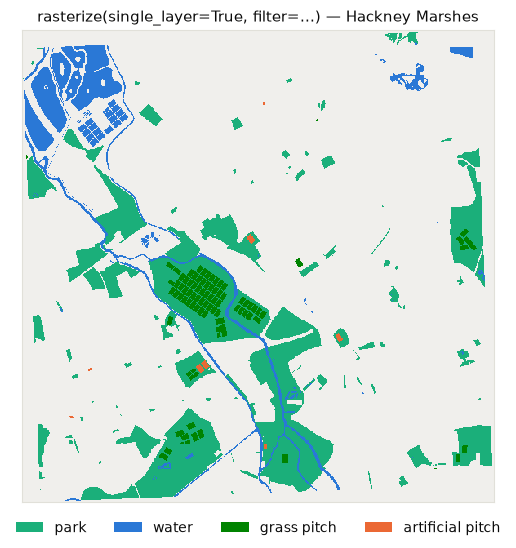

In [5]:
from osm_rasterizer import rasterize

DEMO_BBOX = (-0.06, 51.535, 0.02, 51.585)
demo = rasterize(
    DEMO_BBOX,
    [
        ("park", {"leisure": "park"}),
        ("water", {"natural": "water"}),
        # same tag query, split by the `filter` option into two surface classes:
        ("grass pitch", {"leisure": "pitch"}, {"filter": {"sport": "soccer", "surface": "grass"}}),
        ("artificial pitch", {"leisure": "pitch"},
         {"filter": {"sport": "soccer", "surface": list(SURFACE_GROUPS["artificial"])}}),
    ],
    resolution=10.0,
    single_layer=True,
)
print(f"array {demo.array.shape}, crs {demo.crs}, categories {demo.categories}")

demo_colors = {"park": "#1baf7a", "water": "#2a78d6",
               "grass pitch": "#008300", "artificial pitch": "#eb6834"}
cmap = ListedColormap(["#f0efec"] + [demo_colors[c] for c in demo.categories])
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(demo.array[0], cmap=cmap, vmin=0, vmax=len(demo.categories), interpolation="nearest")
ax.set_title("rasterize(single_layer=True, filter=…) — Hackney Marshes", fontsize=11)
ax.set_xticks([]), ax.set_yticks([])
fig.legend(handles=[Patch(facecolor=demo_colors[c], label=c) for c in demo.categories],
           loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))

## train/val/test split

Neighbouring pixels of a 10 m embedding raster are strongly autocorrelated, so a random pixel split puts one half of a pitch in
train and the other half in test &mdash; and your "accuracy" mostly measures memorisation.

The fix is **spatial blocking**: we tile the AOI with 1 km cells grouped into 3&times;3 blocks and
assign each cell train, val or test from a fixed pattern (5/2/2 &asymp; 56/22/22). Every pitch
inherits the split of the cell containing its **centroid**, so no pitch ever straddles two splits;
negative and background pixels later inherit the split of their cell. Test blocks are therefore
whole neighbourhoods the model has never seen. This was done based on [Tessera's tutorial](https://toao.com/blog/earth-observation-budget-solar-farms-tiny-model) for solar panel detection.

In [6]:
SPLIT_PATTERN = [
    ["train", "test",  "train"],
    ["train", "train", "val"],
    ["val",   "train", "test"],
]
SPLIT_TO_INT = {"train": 1, "val": 2, "test": 3}
SPLIT_COLORS = {"train": "#2a78d6", "val": "#eda100", "test": "#e34948"}

football_split, grid = create_split_grid_and_join(
    bbox_coords=BBOX,
    bbox_crs="EPSG:4326",
    polygons_gdf=football,
    sub_tile_size=1000,
    grid_size=3,
    pattern=SPLIT_PATTERN,
    target_crs=ANALYSIS_CRS,
    join_method="centroid",
)
print(pd.crosstab(football_split.category, football_split.split).to_string())

split       test  train  val
category                    
artificial    80    173   77
grass        212    660  298
hard          18     52   16


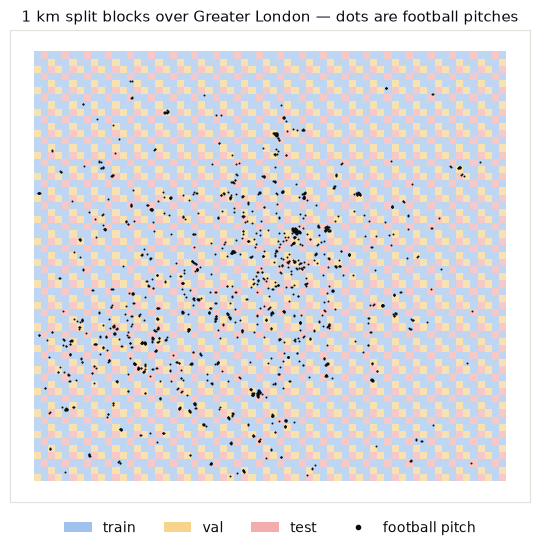

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, color in SPLIT_COLORS.items():
    grid[grid.split == name].plot(ax=ax, color=color, alpha=0.30, edgecolor="none")
cent = football_split.geometry.centroid
ax.scatter(cent.x, cent.y, s=2, color=INK, linewidths=0)
ax.set_title("1 km split blocks over Greater London — dots are football pitches", fontsize=11)
ax.set_xticks([]), ax.set_yticks([])
fig.legend(handles=[Patch(facecolor=c, alpha=0.45, label=s) for s, c in SPLIT_COLORS.items()]
           + [plt.Line2D([], [], marker="o", ls="", color=INK, ms=3, label="football pitch")],
           loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))

## From polygons to training pixels

Now we marry the two data sources. The label schema is a single **declarative feature list** that
`osm_rasterizer.rasterize()` burns onto each embedding tile's exact pixel grid &mdash; the raster
labels are produced entirely by the package, no hand-rolled rasterization. The list order is burn
priority (later wins): negatives first, then the exclusion mask, then the positive surface classes.
Passing each tile's own `transform`/`crs` makes the burned raster align pixel-for-pixel with the
embeddings; `single_layer=True` collapses it to one categorical band we remap to our label ids
(0 background, 1..3 surface classes, 4 hard negative, 255 excluded).

We burn a second raster the same way for the train/val/test **split** (grid cells first, each
pitch's own split on top). Then sampling: **all** positive pixels, plus per tile up to 4k
hard-negative and 12k random background pixels &mdash; a deliberately negative-heavy diet, because
at inference time the model stares at a city that is >99% not-pitch. Tiles are ~630 MB
dequantized, so they're processed one at a time and the sampled arrays cached to `.npz`.

In [8]:
import warnings

import rasterio.transform
from affine import Affine
from rasterio.warp import transform_bounds

LABEL_HARDNEG, LABEL_EXCLUDED = 4, 255
_NEG_NAMES = {"parks", "grassland", "water", "parking", "other_sport"}


def tile_transform(da) -> Affine:
    """Affine transform of a (band, y, x) DataArray with pixel-center coords."""
    resx = float(da.x[1] - da.x[0])
    resy = float(da.y[1] - da.y[0])
    return Affine(resx, 0.0, float(da.x[0]) - resx / 2, 0.0, resy, float(da.y[0]) - resy / 2)


def polys(gdf):
    """Valid (multi)polygons only, geometry column preserved for rasterize()."""
    out = gdf[gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
    return out[out.geometry.is_valid & ~out.geometry.is_empty]


def _football_filter(surfaces):
    return lambda gdf: football_mask(gdf, surfaces)


# The whole label set as osm_rasterizer feature specs (name, source, [options]).
# Negatives + exclusion come from the `filter` option on the raw pitch/landcover
# layers; positives split the pitches by surface. Order = burn priority.
LABEL_FEATURES = [
    ("parks", polys(parks)),
    ("grassland", polys(grass_lu)),
    ("water", polys(water)),
    ("parking", polys(parking)),
    ("other_sport", polys(pitches), {"filter": other_sport_mask}),
    ("excluded", polys(pitches), {"filter": lambda g: excluded_mask(g, KEPT_SURFACES)}),
] + [(f"{c}_pitch", polys(pitches), {"filter": _football_filter(SURFACE_GROUPS[c])})
     for c in keep_cats]

# single_layer returns 1-based category indices in feature order → remap to label ids
LABEL_LUT = np.array(
    [0] + [LABEL_EXCLUDED if n == "excluded" else LABEL_HARDNEG if n in _NEG_NAMES
           else keep_cats.index(n[:-6]) + 1 for n, *_ in LABEL_FEATURES],
    dtype=np.uint8,
)
SPLIT_LUT = np.array([0, 1, 2, 3, 1, 2, 3], dtype=np.uint8)   # cell t/v/te, then pitch t/v/te


def _burn(features, lut, tile_bbox, tr, crs, H, W):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # empty layers on a tile warn; that's fine
        res = rasterize(tile_bbox, features, single_layer=True, transform=tr, crs=crs)
    return lut[res.array[0][:H, :W]]


def burn_labels(tile_bbox, tr, crs, H, W):
    return _burn(LABEL_FEATURES, LABEL_LUT, tile_bbox, tr, crs, H, W)


def burn_split(tile_bbox, tr, crs, H, W):
    feats = [(f"cell_{s}", polys(grid[grid.split == s])) for s in ("train", "val", "test")] \
          + [(f"pitch_{s}", polys(football_split[football_split.split == s])) for s in ("train", "val", "test")]
    return _burn(feats, SPLIT_LUT, tile_bbox, tr, crs, H, W)


print(f"{len(LABEL_FEATURES)} label features → label ids {list(LABEL_LUT)}")
print("  " + " · ".join(n for n, *_ in LABEL_FEATURES))

9 label features → label ids [np.uint8(0), np.uint8(4), np.uint8(4), np.uint8(4), np.uint8(4), np.uint8(4), np.uint8(255), np.uint8(1), np.uint8(2), np.uint8(3)]
  parks · grassland · water · parking · other_sport · excluded · grass_pitch · artificial_pitch · hard_pitch


In [9]:
HARDNEG_PER_TILE = 4000
BG_PER_TILE = 12000
samples_cache = CACHE_DIR / f"samples_{YEAR}_v3.npz"
tile_stats_cache = CACHE_DIR / f"tile_stats_{YEAR}_v3.json"

if samples_cache.exists():
    cached = np.load(samples_cache)
    X, y, split = cached["X"], cached["y"], cached["split"]
    tile_stats = json.loads(tile_stats_cache.read_text())
else:
    Xs, ys, splits_l, tile_stats = [], [], [], []
    for i, tile_dir in enumerate(london_tiles):
        da = open_tile(tile_dir)
        tile_crs = da.rio.crs
        H, W = da.sizes["y"], da.sizes["x"]
        tr = tile_transform(da)

        # tile bounds in WGS84 for rasterize()'s bbox argument
        l, b, r, t = rasterio.transform.array_bounds(H, W, tr)
        tile_bbox = transform_bounds(tile_crs, "EPSG:4326", l, b, r, t)

        label = burn_labels(tile_bbox, tr, tile_crs, H, W)
        split_r = burn_split(tile_bbox, tr, tile_crs, H, W)

        emb = np.asarray(da.values)                    # (128, H, W) float32
        valid = split_r > 0                            # inside the AOI grid
        pos_mask = (label >= 1) & (label < LABEL_HARDNEG) & valid
        hn_mask = (label == LABEL_HARDNEG) & valid
        bg_mask = (label == 0) & valid

        for mask, cap, is_pos in ((pos_mask, None, True),
                                  (hn_mask, HARDNEG_PER_TILE, False),
                                  (bg_mask, BG_PER_TILE, False)):
            r, c = np.nonzero(mask)
            if cap is not None and len(r) > cap:
                sel = rng.choice(len(r), size=cap, replace=False)
                r, c = r[sel], c[sel]
            if len(r) == 0:
                continue
            Xs.append(emb[:, r, c].T.astype(np.float32))
            ys.append(label[r, c].astype(np.uint8) if is_pos else np.zeros(len(r), np.uint8))
            splits_l.append(split_r[r, c].astype(np.uint8))

        tile_stats.append({
            "tile": str(tile_dir),
            "pitch_px": int(pos_mask.sum()),
            "test_pitch_px": int((pos_mask & (split_r == SPLIT_TO_INT["test"])).sum()),
        })
        print(f"[{i + 1:2d}/{len(london_tiles)}] {tile_dir.name}: "
              f"{tile_stats[-1]['pitch_px']:6d} pitch px, {int(hn_mask.sum()):7d} hard-neg px")

    X = np.concatenate(Xs)
    y = np.concatenate(ys)
    split = np.concatenate(splits_l)

    keep = np.abs(X).sum(axis=1) > 0                  # drop any nodata (all-zero) embeddings
    X, y, split = X[keep], y[keep], split[keep]
    np.savez(samples_cache, X=X, y=y, split=split)
    tile_stats_cache.write_text(json.dumps(tile_stats))

print(f"\n{len(X):,} sampled pixels, {X.shape[1]} embedding dims")


1,024,832 sampled pixels, 128 embedding dims


In [10]:
# Cap over-represented positive classes so no single surface dominates training
MAX_PX_PER_POSITIVE_CLASS = 40_000
keep_idx = []
for cls in range(N_CLASSES):
    idx = np.nonzero(y == cls)[0]
    if 1 <= cls and len(idx) > MAX_PX_PER_POSITIVE_CLASS:
        idx = rng.choice(idx, size=MAX_PX_PER_POSITIVE_CLASS, replace=False)
    keep_idx.append(idx)
keep_idx = np.sort(np.concatenate(keep_idx))
X, y, split = X[keep_idx], y[keep_idx], split[keep_idx]

summary = pd.crosstab(pd.Series(y, name="class").map(dict(enumerate(CLASS_NAMES))),
                      pd.Series(split, name="split").map({1: "train", 2: "val", 3: "test"}))
print(summary.to_string())

split               test   train     val
class                                   
artificial pitch    2253    6092    2219
grass pitch         7047   23140    9813
hard pitch           182     521     191
not pitch         211793  532798  213096


## The model: a tiny MLP

This is the whole point of building on a foundation model: the embeddings have already done the
hard perceptual work, so the classifier can be toy-sized &mdash; standardise with train-set
statistics, then 128 &rarr; 64 &rarr; ReLU &rarr; Dropout &rarr; n_classes. It trains in
seconds.

One knob matters for rare classes: the loss weighting. Plain inverse-frequency weights make the
model wildly trigger-happy on the smallest class (our hard-surface pitches have only ~60 training
polygons &mdash; full inverse weighting made an early version of this notebook paint half the
road network orange). We use **&radic;-inverse-frequency** weights instead: rare classes still get
a boost, but not a blank cheque to fire everywhere. Best epoch is selected on validation
macro-F1.

In [ ]:
import copy

import torch
from sklearn.metrics import f1_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN, VAL, TEST = 1, 2, 3
mu = X[split == TRAIN].mean(axis=0)
sd = X[split == TRAIN].std(axis=0) + 1e-6
Xn = (X - mu) / sd


def subset(s):
    m = split == s
    return torch.from_numpy(Xn[m]), torch.from_numpy(y[m].astype(np.int64))


X_tr, y_tr = subset(TRAIN)
X_va, y_va = subset(VAL)
X_te, y_te = subset(TEST)

model = nn.Sequential(
    nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, N_CLASSES),
).to(device)

counts = np.bincount(y_tr.numpy(), minlength=N_CLASSES).astype(np.float64)
class_w = 1.0 / np.sqrt(counts)                      # sqrt-inverse frequency: boost rare
class_w *= N_CLASSES / class_w.sum()                 # classes without letting them over-fire
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_w, dtype=torch.float32, device=device))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=4096, shuffle=True)


@torch.no_grad()
def predict_proba(Xt, batch=65_536):
    model.eval()
    return torch.cat([torch.softmax(model(Xt[i:i + batch].to(device)), dim=1).cpu()
                      for i in range(0, len(Xt), batch)]).numpy()


def predict(Xt):
    return predict_proba(Xt).argmax(axis=1)


EPOCHS = 30
history, best_f1, best_state = [], -1.0, None
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        opt.zero_grad()
        loss = loss_fn(model(xb.to(device)), yb.to(device))
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(X_tr)
    val_f1 = f1_score(y_va.numpy(), predict(X_va), average="macro",
                      labels=list(range(N_CLASSES)), zero_division=0)
    history.append((epoch_loss, val_f1))
    if val_f1 > best_f1:
        best_f1, best_state = val_f1, copy.deepcopy(model.state_dict())
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d}  train loss {epoch_loss:.4f}  val macro-F1 {val_f1:.4f}")

model.load_state_dict(best_state)
print(f"\nbest val macro-F1: {best_f1:.4f} ({device})")

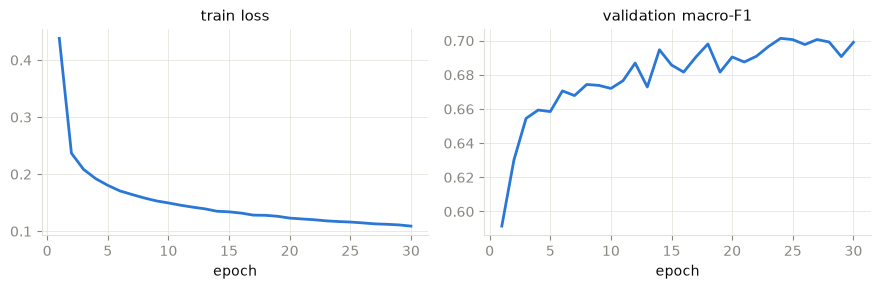

In [ ]:
losses, val_f1s = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(range(1, EPOCHS + 1), losses, color="#2a78d6", lw=2)
axes[0].set_title("train loss", fontsize=11)
axes[1].plot(range(1, EPOCHS + 1), val_f1s, color="#2a78d6", lw=2)
axes[1].set_title("validation macro-F1", fontsize=11)
for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(color=GRID_LINE, lw=0.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()

## Does it actually work? Held-out evaluation

The test set comes from spatial blocks the model has never seen &mdash; whole neighbourhoods,
not neighbouring pixels. As a reference point, a majority-class predictor scores essentially 0.2
macro-F1 here, so anything well above that reflects real signal in the embeddings, not
memorised geography.

                  precision    recall  f1-score   support

       not pitch      0.993     0.980     0.986    211793
     grass pitch      0.610     0.808     0.695      7047
artificial pitch      0.746     0.820     0.781      2253
      hard pitch      0.100     0.192     0.132       182

        accuracy                          0.972    221275
       macro avg      0.612     0.700     0.649    221275
    weighted avg      0.977     0.972     0.974    221275



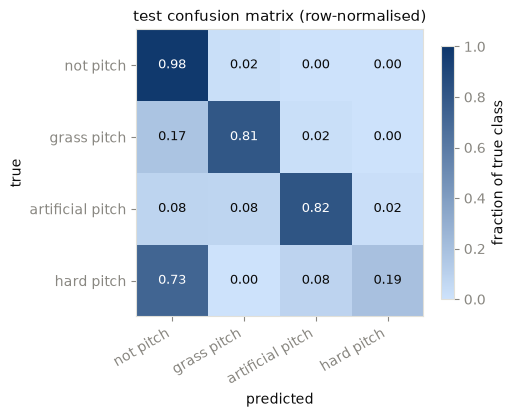

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

pred_te = predict(X_te)
print(classification_report(y_te.numpy(), pred_te, labels=list(range(N_CLASSES)),
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

cm = confusion_matrix(y_te.numpy(), pred_te, labels=list(range(N_CLASSES)), normalize="true")
blues = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#0d366b"])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(cm, cmap=blues, vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=30, ha="right")
ax.set_yticks(range(N_CLASSES), CLASS_NAMES)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if cm[i, j] > 0.5 else INK)
ax.set_xlabel("predicted"), ax.set_ylabel("true")
ax.set_title("test confusion matrix (row-normalised)", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label="fraction of true class")
plt.tight_layout()

### Trading recall for precision, on purpose

Raw argmax treats a 40% -confident guess the same as a 99% one. For a detector that will scan
millions of pixels, that's a recipe for false-positive confetti &mdash; especially from the rare
hard-surface class. The fix costs three lines: predictions below a **confidence threshold** fall
back to "not pitch". We sweep the threshold on the validation split (never on test) to see the
precision/recall trade-off &mdash; validation macro-F1 peaks around the middle of the range, then
falls as recall drains away. For the city-wide map we deliberately pick a **precision-favouring
operating point of 0.8**: a few real pitches go undetected, but the map stays clean instead of
speckled. All test metrics below are reported at that threshold.

In [14]:
val_probs = predict_proba(X_va)
val_conf, val_pred = val_probs.max(axis=1), val_probs.argmax(axis=1)

sweep = []
for t in np.arange(0.50, 0.96, 0.05):
    p = np.where(val_conf >= t, val_pred, 0)
    sweep.append((round(float(t), 2),
                  f1_score(y_va.numpy(), p, average="macro",
                           labels=list(range(N_CLASSES)), zero_division=0)))
print(pd.DataFrame(sweep, columns=["threshold", "val macro-F1"]).to_string(index=False))

f1_optimal = max(sweep, key=lambda r: r[1])[0]
CONF_THRESHOLD = 0.8                                  # precision-favouring operating point
print(f"\nF1-optimal threshold: {f1_optimal}   |   chosen (precision-favouring): {CONF_THRESHOLD}")

test_probs = predict_proba(X_te)
pred_te_conf = np.where(test_probs.max(axis=1) >= CONF_THRESHOLD,
                        test_probs.argmax(axis=1), 0)
print(f"\ntest metrics at conf ≥ {CONF_THRESHOLD}:")
print(classification_report(y_te.numpy(), pred_te_conf, labels=list(range(N_CLASSES)),
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

 threshold  val macro-F1
      0.50      0.706266
      0.55      0.707893
      0.60      0.710736
      0.65      0.708809
      0.70      0.703261
      0.75      0.685587
      0.80      0.666088
      0.85      0.638994
      0.90      0.599790
      0.95      0.546259

F1-optimal threshold: 0.6   |   chosen (precision-favouring): 0.8

test metrics at conf ≥ 0.8:
                  precision    recall  f1-score   support

       not pitch      0.984     0.992     0.988    211793
     grass pitch      0.733     0.593     0.656      7047
artificial pitch      0.849     0.704     0.770      2253
      hard pitch      0.145     0.044     0.068       182

        accuracy                          0.976    221275
       macro avg      0.678     0.583     0.620    221275
    weighted avg      0.974     0.976     0.974    221275



## A closer look at one tile

Time to see it. First a detail view: we run the classifier over **every pixel** of the tile with
the most held-out (test) pitch pixels &mdash; applying the validation-calibrated confidence
threshold &mdash; and compare against the OSM outlines. The backdrop is a 3-component PCA of the
tile's own embeddings, the standard way to eyeball what the foundation model "sees". (The
whole-city interactive map comes right after.)

In [15]:
from sklearn.decomposition import PCA

stats = pd.DataFrame(tile_stats)
best_tile = Path(stats.loc[stats.test_pitch_px.idxmax(), "tile"])
print(f"inference tile: {best_tile.name} "
      f"({int(stats.test_pitch_px.max()):,} test pitch px)")

da = open_tile(best_tile)
tile_crs = da.rio.crs
H, W = da.sizes["y"], da.sizes["x"]
tr = tile_transform(da)
flat = np.asarray(da.values).reshape(128, -1).T          # (H*W, 128)

# per-pixel class probabilities
Xn_flat = torch.from_numpy(((flat - mu) / sd).astype(np.float32))
probs = predict_proba(Xn_flat)
pred_map = probs.argmax(axis=1).reshape(H, W)
conf_map = probs.max(axis=1).reshape(H, W)

# PCA-RGB backdrop
pca = PCA(3, random_state=SEED).fit(flat[rng.choice(len(flat), 50_000, replace=False)])
comp = pca.transform(flat)
lo, hi = np.percentile(comp, [2, 98], axis=0)
rgb = np.clip((comp - lo) / (hi - lo), 0, 1).reshape(H, W, 3)

inference tile: grid_-0.35_51.45 (1,786 test pitch px)


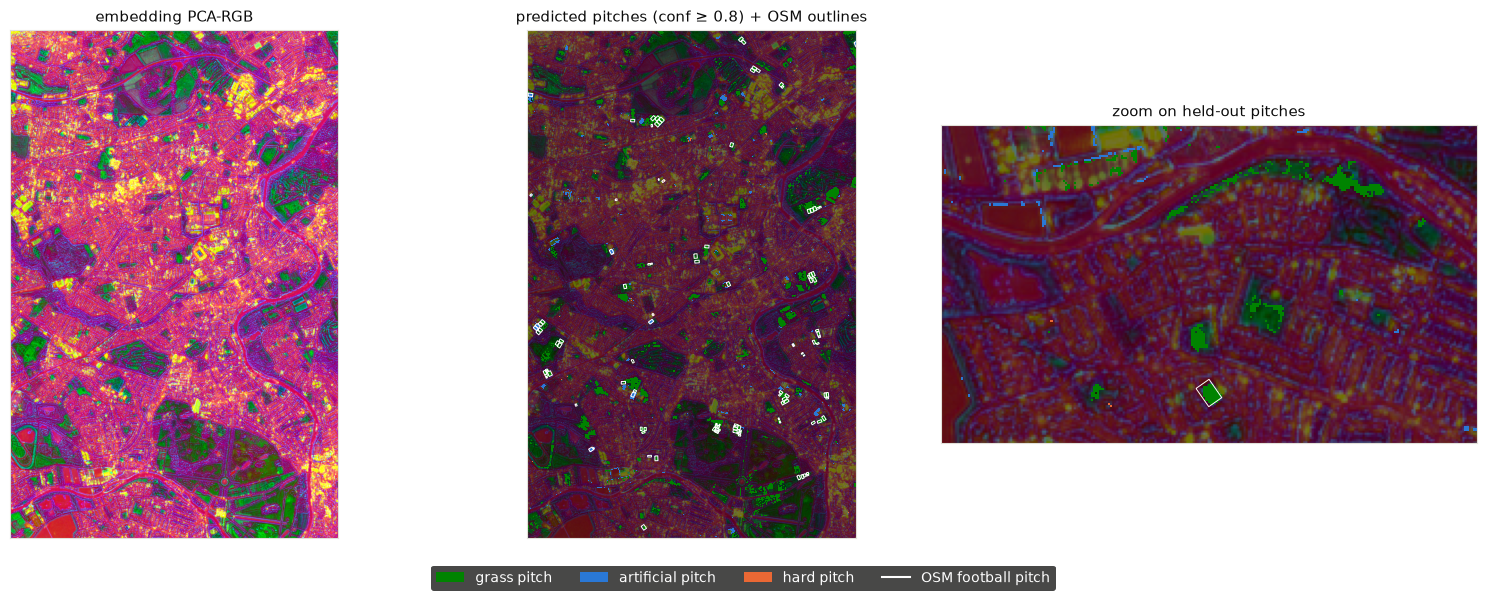

In [16]:
import rasterio.transform

CLASS_COLORS = ["#008300", "#2a78d6", "#eb6834"][: N_CLASSES - 1]   # grass, artificial, hard

left, bottom, right, top = rasterio.transform.array_bounds(H, W, tr)
extent = (left, right, bottom, top)
fp_tile = football_split.to_crs(tile_crs)
fp_tile = fp_tile[fp_tile.intersects(box(*[left, bottom, right, top]))]

overlay = np.ma.masked_where((pred_map == 0) | (conf_map < CONF_THRESHOLD), pred_map)
cls_cmap = ListedColormap(CLASS_COLORS)
cls_norm = BoundaryNorm(np.arange(0.5, N_CLASSES + 0.5), N_CLASSES - 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(rgb, extent=extent)
axes[0].set_title("embedding PCA-RGB", fontsize=11)
for ax in axes[1:]:
    ax.imshow(rgb * 0.45, extent=extent)
    ax.imshow(overlay, cmap=cls_cmap, norm=cls_norm, extent=extent, interpolation="nearest")
    fp_tile.boundary.plot(ax=ax, color="white", linewidth=0.7)
axes[1].set_xlim(left, right), axes[1].set_ylim(bottom, top)
axes[1].set_title(f"predicted pitches (conf ≥ {CONF_THRESHOLD}) + OSM outlines", fontsize=11)

# zoom on the largest held-out pitch (with the whole cluster around it)
test_fp = fp_tile[fp_tile.split == "test"] if (fp_tile.split == "test").any() else fp_tile
zx0, zy0, zx1, zy1 = test_fp.loc[test_fp.area.idxmax()].geometry.bounds
pad = 1200
axes[2].set_xlim(max(left, zx0 - pad), min(right, zx1 + pad))
axes[2].set_ylim(max(bottom, zy0 - pad), min(top, zy1 + pad))
axes[2].set_title("zoom on held-out pitches", fontsize=11)

for ax in axes:
    ax.set_xticks([]), ax.set_yticks([])
fig.legend(handles=[Patch(facecolor=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES[1:])]
           + [plt.Line2D([], [], color="white", lw=1.5, label="OSM football pitch")],
           loc="lower center", ncol=4, frameon=True, facecolor="#1a1a19",
           labelcolor="white", edgecolor="none", fontsize=10)
plt.tight_layout(rect=(0, 0.07, 1, 1))

### The whole city: predictions

We run the model over all 60 tiles to get a full map of football pitches

In [ ]:
#|output: false
import rasterio
from rasterio.transform import array_bounds, from_origin
from rasterio.warp import Resampling, reproject, transform_bounds
from rasterio.windows import Window
from rasterio.windows import transform as window_transform

gminx, gminy, gmaxx, gmaxy = BBOX

# ── grid 1: native 10 m, British National Grid — the saved GeoTIFF ──
BNG_CRS, BNG_RES = "EPSG:27700", 10.0
_bx0, _by0, _bx1, _by1 = transform_bounds("EPSG:4326", BNG_CRS, *BBOX)
bminx, bmaxy = np.floor(_bx0 / BNG_RES) * BNG_RES, np.ceil(_by1 / BNG_RES) * BNG_RES
BW = int(np.ceil((_bx1 - bminx) / BNG_RES))
BH = int(np.ceil((bmaxy - _by0) / BNG_RES))
BNG_TRANSFORM = from_origin(bminx, bmaxy, BNG_RES, BNG_RES)

# ── grid 2: ~15 m WGS84 — only for the folium overlay ──
MOSAIC_RES = 0.00015
GW, GH = int(np.ceil((gmaxx - gminx) / MOSAIC_RES)), int(np.ceil((gmaxy - gminy) / MOSAIC_RES))
G_TRANSFORM = from_origin(gminx, gmaxy, MOSAIC_RES, MOSAIC_RES)

mosaic_cache = CACHE_DIR / f"london_pred_mosaic_{YEAR}.npy"
bng_cache = CACHE_DIR / f"london_pred_bng10m_{YEAR}.npy"
GEOTIFF_PATH = CACHE_DIR / f"london_football_pitches_{YEAR}_10m.tif"


def _paste(pred, src_tr, src_crs, grid, grid_tr, dst_crs, res, ox, oy):
    """Reproject a tile prediction into a window of `grid` (nearest, later wins)."""
    tl, tb, tr_, tt = array_bounds(*pred.shape, src_tr)
    wl, wb, wr, wt = transform_bounds(src_crs, dst_crs, tl, tb, tr_, tt)
    c0 = max(0, int(np.floor((wl - ox) / res)));  c1 = min(grid.shape[1], int(np.ceil((wr - ox) / res)))
    r0 = max(0, int(np.floor((oy - wt) / res)));  r1 = min(grid.shape[0], int(np.ceil((oy - wb) / res)))
    if c1 <= c0 or r1 <= r0:
        return
    win = Window(c0, r0, c1 - c0, r1 - r0)
    dst = np.zeros((r1 - r0, c1 - c0), dtype=np.uint8)
    reproject(pred, dst, src_transform=src_tr, src_crs=src_crs,
              dst_transform=window_transform(win, grid_tr), dst_crs=dst_crs,
              resampling=Resampling.nearest)
    grid[r0:r1, c0:c1] = np.where(dst > 0, dst, grid[r0:r1, c0:c1])


if mosaic_cache.exists() and bng_cache.exists():
    mosaic, bng = np.load(mosaic_cache), np.load(bng_cache)
else:
    mosaic = np.zeros((GH, GW), dtype=np.uint8)
    bng = np.zeros((BH, BW), dtype=np.uint8)
    for k, tile_dir in enumerate(london_tiles):
        t_da = open_tile(tile_dir)
        t_crs, t_h, t_w = t_da.rio.crs, t_da.sizes["y"], t_da.sizes["x"]
        t_tr = tile_transform(t_da)
        t_flat = np.asarray(t_da.values).reshape(128, -1).T
        t_prob = predict_proba(torch.from_numpy(((t_flat - mu) / sd).astype(np.float32)))
        t_pred = t_prob.argmax(axis=1).astype(np.uint8)
        t_pred[t_prob.max(axis=1) < CONF_THRESHOLD] = 0
        t_pred = t_pred.reshape(t_h, t_w)

        _paste(t_pred, t_tr, t_crs, bng, BNG_TRANSFORM, BNG_CRS, BNG_RES, bminx, bmaxy)
        _paste(t_pred, t_tr, t_crs, mosaic, G_TRANSFORM, "EPSG:4326", MOSAIC_RES, gminx, gmaxy)
        print(f"[{k + 1:2d}/{len(london_tiles)}] {tile_dir.name} mosaicked")
    np.save(mosaic_cache, mosaic)
    np.save(bng_cache, bng)

# ── write the georeferenced GeoTIFF (10 m, EPSG:27700, with a class colormap) ──
CLASS_RGB = {1: (0, 131, 0), 2: (42, 120, 214), 3: (235, 104, 52)}   # grass / artificial / hard
with rasterio.open(
    GEOTIFF_PATH, "w", driver="GTiff", height=BH, width=BW, count=1, dtype="uint8",
    crs=BNG_CRS, transform=BNG_TRANSFORM, nodata=0, compress="lzw", tiled=True,
) as dst:
    dst.write(bng, 1)
    dst.write_colormap(1, {0: (0, 0, 0, 0), **{v: (*rgb, 255) for v, rgb in CLASS_RGB.items()}})
    dst.update_tags(1, CLASSES="; ".join(f"{i + 1}={n}" for i, n in enumerate(CLASS_NAMES[1:])))

n_pitch_px = int((bng > 0).sum())
print(f"\nGeoTIFF: {GEOTIFF_PATH}")
print(f"  {BH}×{BW} px @ 10 m {BNG_CRS} · {n_pitch_px:,} predicted pitch px "
      f"({100 * n_pitch_px / bng.size:.2f}% of the AOI)")

[ 1/60] grid_-0.05_51.25 mosaicked


[ 2/60] grid_-0.05_51.35 mosaicked


[ 3/60] grid_-0.05_51.45 mosaicked


[ 4/60] grid_-0.05_51.55 mosaicked


[ 5/60] grid_-0.05_51.65 mosaicked


...

[57/60] grid_0.35_51.45 mosaicked


[58/60] grid_0.35_51.55 mosaicked


[59/60] grid_0.35_51.65 mosaicked


[60/60] grid_0.35_51.75 mosaicked



GeoTIFF: /maps/acz25/phd-thesis-data/output/osm_football_cache/london_football_pitches_2025_10m.tif
  5723×6392 px @ 10 m EPSG:27700 · 352,406 predicted pitch px (0.96% of the AOI)


### The interactive map

Static maps don't do the model justice &mdash; the fun is seeing it against actual imagery and OSM data. Toggle the options to see different basemaps and the predicted football pitches in the Greater London Area. Have a look at how many artificial and hard pitches there are in the city, and how many pitches are actually missing from OSM.


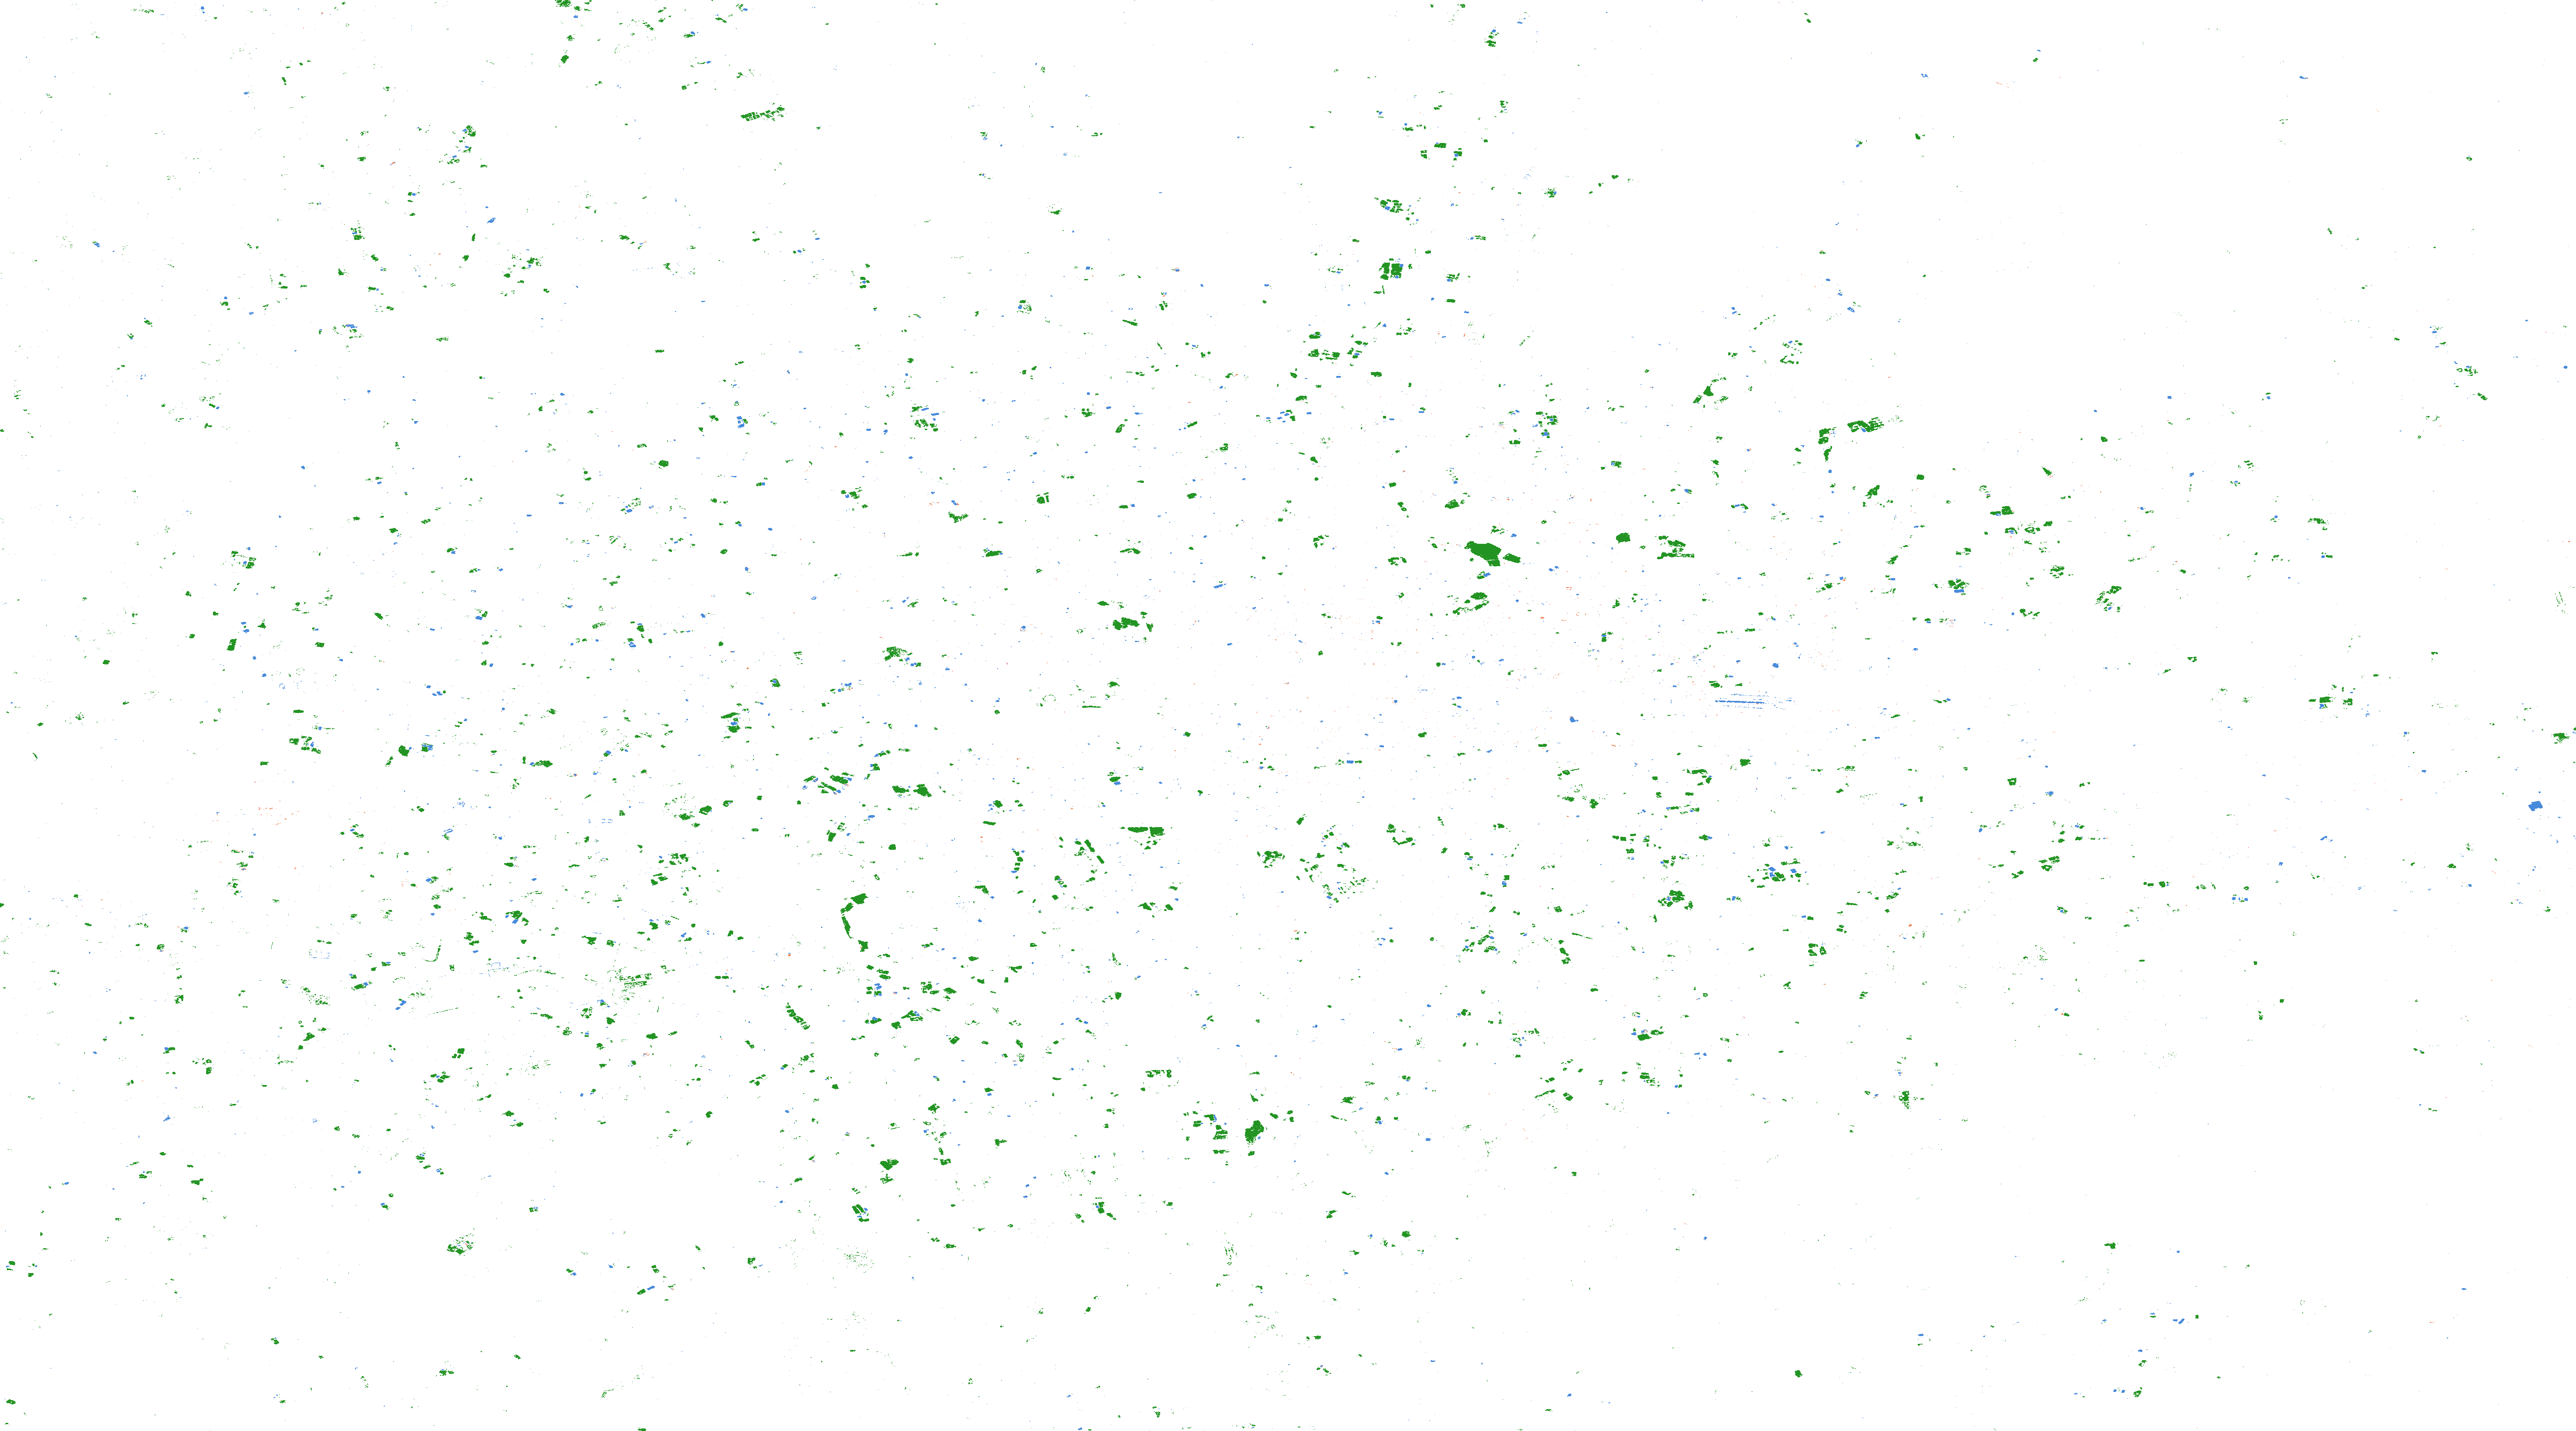

In [18]:
import folium
from matplotlib.colors import to_rgb

rgba = np.zeros((*mosaic.shape, 4), dtype=np.uint8)
for cls_id, color in enumerate(CLASS_COLORS, start=1):
    rgba[mosaic == cls_id] = tuple(int(255 * v) for v in to_rgb(color)) + (220,)

# Bounds must be the TRUE pixel-grid extent, not BBOX: the grid is ceil()-rounded
# so it is a fraction of a pixel larger than BBOX. Passing BBOX would make Leaflet
# stretch the image and shift predictions a few metres off the OSM polygons.
grid_south = gmaxy - mosaic.shape[0] * MOSAIC_RES
grid_east = gminx + mosaic.shape[1] * MOSAIC_RES

fmap = folium.Map(location=[(gminy + gmaxy) / 2, (gminx + gmaxx) / 2],
                  zoom_start=11, tiles="OpenStreetMap")
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    attr="Google", name="Google Satellite",
).add_to(fmap)
folium.raster_layers.ImageOverlay(
    image=rgba, bounds=[[grid_south, gminx], [gmaxy, grid_east]],
    name=f"predicted pitches (conf ≥ {CONF_THRESHOLD})",
).add_to(fmap)
folium.GeoJson(
    football_split.to_crs("EPSG:4326")[["geometry", "category", "split"]],
    name="OSM football pitches",
    style_function=lambda f: {"color": "#0b0b0b", "weight": 1.5, "fill": False},
    tooltip=folium.GeoJsonTooltip(fields=["category", "split"]),
).add_to(fmap)
folium.LayerControl().add_to(fmap)

legend_items = "".join(
    f'<span style="display:inline-block;width:12px;height:12px;background:{c};'
    f'margin:0 4px 0 10px;vertical-align:-1px;"></span>{n}'
    for c, n in zip(CLASS_COLORS, CLASS_NAMES[1:])
)
fmap.get_root().html.add_child(folium.Element(
    '<div style="position:fixed;bottom:16px;left:16px;z-index:9999;background:white;'
    'color:#0b0b0b;padding:6px 10px;border-radius:4px;font:12px system-ui;'
    f'box-shadow:0 1px 4px rgba(0,0,0,.3);">{legend_items}</div>'
))
fmap